In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))


fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000
fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


# Paths
Final_data_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
output_dir = "/content/Final_split"

# Classes (from your final dataset)
classes = ["fresh", "infected"] # Removed "Unknown"

# Clean old split if exists
shutil.rmtree(output_dir, ignore_errors=True)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

random.seed(42)  # reproducibility

for cls in classes:
    class_dir = os.path.join(Final_data_path, cls)

    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {cls} because folder not found")
        continue

    all_files = [f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # First split: train vs temp (val+test)
    train_files, temp_files = train_test_split(
        all_files, test_size=1-train_ratio, random_state=42
    )

    # Second split: val vs test
    val_files, test_files = train_test_split(
        temp_files, test_size=test_ratio/(val_ratio+test_ratio), random_state=42
    )

    # Copy files to respective directories
    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "train", cls, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "val", cls, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "test", cls, f)
        shutil.copy2(src, dst)

    print(f"✅ {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print("\n🎯 Dataset split completed!")

✅ fresh: 4000 train, 500 val, 500 test
✅ infected: 4000 train, 500 val, 500 test

🎯 Dataset split completed!


Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,073 (98.49 MB)

 Trainable params: 25,817,857 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 468ms/step - accuracy: 0.9630 - loss: 0.1276 - val_accuracy: 0.5010 - val_loss: 1.7859
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 433ms/step - accuracy: 0.9925 - loss: 0.0373 - val_accuracy: 0.9130 - val_loss: 0.2005
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 145s 446ms/step - accuracy: 0.9936 - loss: 0.0273 - val_accuracy: 0.9970 - val_loss: 0.0149
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 114s 455ms/step - accuracy: 0.9961 - loss: 0.0194 - val_accuracy: 0.9960 - val_loss: 0.0164
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 416ms/step - accuracy: 0.9983 - loss: 0.0124 - val_accuracy: 0.9940 - val_loss: 0.0214
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 409ms/step - accuracy: 0.9977 - loss: 0.0114 - val_accuracy: 0.9930 - val_loss: 0.0296
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 441ms/step - accuracy: 0.9969 - loss: 0.0112 - val_accuracy: 0.9980 - val_loss: 0.0155
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 419ms/step - accuracy: 0.9983 -

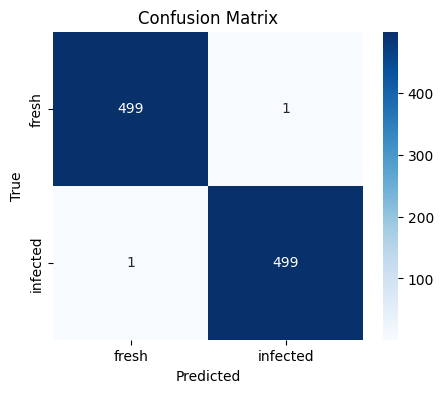


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    0.9980    0.9980       500
    infected     0.9980    0.9980    0.9980       500

    accuracy                         0.9980      1000
   macro avg     0.9980    0.9980    0.9980      1000
weighted avg     0.9980    0.9980    0.9980      1000


🔹 Macro Average Accuracy (Precision Avg): 0.9980
🔹 Overall Test Accuracy: 0.9980


In [ ]:
# --------------------------
# CNN (Fresh vs Infected) - Sigmoid Version
# --------------------------
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators (CHANGED)
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=False
)

# --------------------------
# CNN Model (CHANGED FINAL LAYER)
# --------------------------
model_cnn = Sequential([
    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(1, activation='sigmoid')   # ✅ changed
])

# --------------------------
# Compile (CHANGED)
# --------------------------
model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',   # ✅ changed
    metrics=['accuracy']
)

model_cnn.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_cnn_model.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Evaluation (CHANGED PREDICTION)
# --------------------------
y_pred = model_cnn.predict(test_gen)

# ✅ sigmoid threshold
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg): {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")

Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             

 Total params: 14,880,577 (56.76 MB)

 Trainable params: 165,121 (645.00 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 471ms/step - accuracy: 0.9009 - loss: 0.2597 - val_accuracy: 0.9670 - val_loss: 0.2589
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 518ms/step - accuracy: 0.9845 - loss: 0.0752 - val_accuracy: 0.9930 - val_loss: 0.0458
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 116s 463ms/step - accuracy: 0.9923 - loss: 0.0443 - val_accuracy: 0.9950 - val_loss: 0.0211
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 148s 487ms/step - accuracy: 0.9925 - loss: 0.0351 - val_accuracy: 0.9990 - val_loss: 0.0137
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 113s 451ms/step - accuracy: 0.9946 - loss: 0.0265 - val_accuracy: 0.9990 - val_loss: 0.0104
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 117s 467ms/step - accuracy: 0.9966 - loss: 0.0197 - val_accuracy: 0.9990 - val_loss: 0.0078
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 459ms/step - accuracy: 0.9962 - loss: 0.0176 - val_accuracy: 0.9990 - val_loss: 0.0060
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 140s 450ms/step - accuracy: 0.9969 -

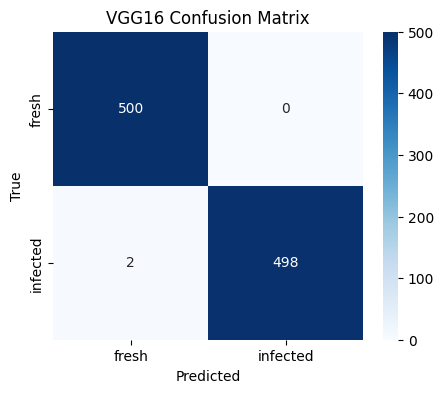


Classification Report:

              precision    recall  f1-score   support

       fresh   0.996016  1.000000  0.998004       500
    infected   1.000000  0.996000  0.997996       500

    accuracy                       0.998000      1000
   macro avg   0.998008  0.998000  0.998000      1000
weighted avg   0.998008  0.998000  0.998000      1000


🔹 Macro Precision: 0.998008
🔹 Macro Recall: 0.998000
🔹 Macro F1 Score: 0.998000
🔹 Overall Test Accuracy: 0.998000


In [ ]:
# --------------------------
# VGG16 (Fresh vs Infected) - FULL PIPELINE
# --------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & Parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# --------------------------
# VGG16 Base Model
# --------------------------
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# --------------------------
# Custom Head
# --------------------------
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.5)(x)

x = Dense(128)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

# --------------------------
# Compile
# --------------------------
model_vgg16.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg16.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_vgg16_model.keras"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train
# --------------------------
history = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Evaluation
# --------------------------
y_pred = model_vgg16.predict(test_gen)
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VGG16 Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    digits=6,
    output_dict=True
)

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    digits=6
))

# --------------------------
# Metrics (Same Style as Your CNN)
# --------------------------

# Macro Precision (your "macro accuracy")
macro_precision = np.mean([report[cls]['precision'] for cls in class_names])

# Macro Recall
macro_recall = np.mean([report[cls]['recall'] for cls in class_names])

# Macro F1
macro_f1 = np.mean([report[cls]['f1-score'] for cls in class_names])

# Overall Accuracy
overall_acc = np.mean(y_true == y_pred_classes)

print(f"\n🔹 Macro Precision: {macro_precision:.6f}")
print(f"🔹 Macro Recall: {macro_recall:.6f}")
print(f"🔹 Macro F1 Score: {macro_f1:.6f}")
print(f"🔹 Overall Test Accuracy: {overall_acc:.6f}")

In [ ]:
import os
import pandas as pd

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

filepaths = []
labels = []

for label in classes:
    class_path = os.path.join(dataset_path, label)

    for img in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, img))
        labels.append(label)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

print(df.head())
print("Total samples:", len(df))

                                            filename  class
0  /content/drive/MyDrive/Chickpeas Classificatio...  fresh
1  /content/drive/MyDrive/Chickpeas Classificatio...  fresh
2  /content/drive/MyDrive/Chickpeas Classificatio...  fresh
3  /content/drive/MyDrive/Chickpeas Classificatio...  fresh
4  /content/drive/MyDrive/Chickpeas Classificatio...  fresh
Total samples: 10000


In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32
epochs = 10

train_datagen = ImageDataGenerator(rescale=1./255)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from scipy import stats

# --------------------------
# VGG16 Feature Extractor
# --------------------------
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
def extract_features(generator):
    features, labels = [], []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)

        features.append(feat)
        labels.append(y_batch)

    features = np.vstack(features)
    labels = np.hstack(labels)

    return features, labels

In [ ]:
# ⚠️ VERY IMPORTANT (avoid mismatch)
train_gen.shuffle = False

print("Extracting features using VGG16...")
X, y = extract_features(train_gen)

print("Feature shape:", X.shape)

Extracting features using VGG16...
Feature shape: (8000, 512)


In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

precisions, recalls, f1s, accuracies = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_val)

    precision = precision_score(y_val, y_pred, average='macro')
    recall    = recall_score(y_val, y_pred, average='macro')
    f1        = f1_score(y_val, y_pred, average='macro')
    acc       = accuracy_score(y_val, y_pred)

    print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    accuracies.append(acc)

Fold 1: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 2: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 3: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 4: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 5: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 6: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 7: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 8: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 10: Precision=0.9963, Recall=0.9963, F1=0.9962, Accuracy=0.9962


In [ ]:
print("\n===== 10-Fold CV Average Metrics =====")
print(f"Macro Precision: {np.mean(precisions):.4f}")
print(f"Macro Recall:    {np.mean(recalls):.4f}")
print(f"Macro F1-score:  {np.mean(f1s):.4f}")
print(f"Accuracy:        {np.mean(accuracies):.4f}")


===== 10-Fold CV Average Metrics =====
Macro Precision: 0.9985
Macro Recall:    0.9985
Macro F1-score:  0.9985
Accuracy:        0.9985


In [ ]:
# =========================================
# 🔹 1. IMPORTS
# =========================================
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from scipy import stats

# =========================================
# 🔹 2. VGG16 FEATURE EXTRACTOR
# =========================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# =========================================
# 🔹 3. FEATURE EXTRACTION FUNCTION
# =========================================
def extract_features(generator):
    features, labels = [], []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)

        features.append(feat)
        labels.append(y_batch)

    features = np.vstack(features)
    labels = np.hstack(labels)

    return features, labels

# =========================================
# 🔹 4. EXTRACT FEATURES
# =========================================
train_gen.shuffle = False   # ⚠️ VERY IMPORTANT

print("Extracting features using VGG16...")
X, y = extract_features(train_gen)

print("Feature shape:", X.shape)

# =========================================
# 🔹 5. FEATURE SCALING (IMPORTANT)
# =========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================================
# 🔹 6. CLASSIFIERS
# =========================================
classifiers = {
    "SVM": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42)
}

# =========================================
# 🔹 7. K-FOLD SETUP
# =========================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

# =========================================
# 🔹 8. TRAIN + EVALUATE
# =========================================
for name, clf in classifiers.items():
    print(f"\n===== {name} =====")

    precisions, recalls, f1s, accuracies = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_val)

        precision = precision_score(y_val, y_pred, average='macro')
        recall    = recall_score(y_val, y_pred, average='macro')
        f1        = f1_score(y_val, y_pred, average='macro')
        acc       = accuracy_score(y_val, y_pred)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracies.append(acc)

        print(f"Fold {fold}: Acc={acc:.6f}, F1={f1:.6f}")

    results[name] = {
        "precision": precisions,
        "recall": recalls,
        "f1": f1s,
        "accuracy": accuracies
    }

# =========================================
# 🔹 9. CONFIDENCE INTERVAL FUNCTION
# =========================================
def compute_ci(data):
    mean = np.mean(data)
    std = np.std(data)
    n = len(data)

    ci = stats.t.interval(
        0.95,
        df=n-1,
        loc=mean,
        scale=std/np.sqrt(n)
    )

    return mean, ci

# =========================================
# 🔹 10. FINAL RESULTS (6 DECIMAL + CI)
# =========================================
print("\n===== FINAL RESULTS =====")

for name in classifiers.keys():
    print(f"\n🔹 {name}")

    acc_mean, acc_ci = compute_ci(results[name]["accuracy"])
    f1_mean, f1_ci   = compute_ci(results[name]["f1"])
    prec_mean, prec_ci = compute_ci(results[name]["precision"])
    rec_mean, rec_ci   = compute_ci(results[name]["recall"])

    print(f"Accuracy : {acc_mean:.6f} ({acc_ci[0]:.6f}, {acc_ci[1]:.6f})")
    print(f"F1-score : {f1_mean:.6f} ({f1_ci[0]:.6f}, {f1_ci[1]:.6f})")
    print(f"Precision: {prec_mean:.6f} ({prec_ci[0]:.6f}, {prec_ci[1]:.6f})")
    print(f"Recall   : {rec_mean:.6f} ({rec_ci[0]:.6f}, {rec_ci[1]:.6f})")

Extracting features using VGG16...
Feature shape: (8000, 512)

===== SVM =====
Fold 1: Acc=0.998750, F1=0.998750
Fold 2: Acc=0.998750, F1=0.998750
Fold 3: Acc=0.998750, F1=0.998750
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=0.998750, F1=0.998750
Fold 6: Acc=0.998750, F1=0.998750
Fold 7: Acc=0.997500, F1=0.997500
Fold 8: Acc=0.998750, F1=0.998750
Fold 9: Acc=0.997500, F1=0.997500
Fold 10: Acc=0.998750, F1=0.998750

===== KNN =====
Fold 1: Acc=1.000000, F1=1.000000
Fold 2: Acc=0.996250, F1=0.996250
Fold 3: Acc=1.000000, F1=1.000000
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=0.998750, F1=0.998750
Fold 6: Acc=0.998750, F1=0.998750
Fold 7: Acc=0.995000, F1=0.995000
Fold 8: Acc=1.000000, F1=1.000000
Fold 9: Acc=0.998750, F1=0.998750
Fold 10: Acc=0.993750, F1=0.993750

===== RF =====
Fold 1: Acc=0.998750, F1=0.998750
Fold 2: Acc=1.000000, F1=1.000000
Fold 3: Acc=0.997500, F1=0.997500
Fold 4: Acc=0.997500, F1=0.997500
Fold 5: Acc=0.998750, F1=0.998750
Fold 6: Acc=0.998750, F1=0.998750
Fo

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# =========================================
# 🔹 1. BASE MODEL (VGG19)
# =========================================
base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# =========================================
# 🔹 2. CUSTOM HEAD
# =========================================
x = GlobalAveragePooling2D()(base_model.output)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_vgg19 = Model(inputs=base_model.input, outputs=output)

# =========================================
# 🔹 3. COMPILE
# =========================================
model_vgg19.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()

# =========================================
# 🔹 4. TRAIN
# =========================================
history = model_vgg19.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,188,737 (77.01 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 171s 671ms/step - accuracy: 0.6314 - loss: 0.6379 - val_accuracy: 0.9050 - val_loss: 0.4439
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 166s 664ms/step - accuracy: 0.8609 - loss: 0.3799 - val_accuracy: 0.9780 - val_loss: 0.1870
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 161s 643ms/step - accuracy: 0.9454 - loss: 0.1972 - val_accuracy: 0.9915 - val_loss: 0.0842
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 158s 632ms/step - accuracy: 0.9714 - loss: 0.1170 - val_accuracy: 0.9920 - val_loss: 0.0534
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 633ms/step - accuracy: 0.9805 - loss: 0.0762 - val_accuracy: 0.9915 - val_loss: 0.0422
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 156s 626ms/step - accuracy: 0.9860 - loss: 0.0560 - val_accuracy: 0.9945 - val_loss: 0.0272
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 157s 630ms/step - accuracy: 0.9884 - loss: 0.0445 - val_accuracy: 0.9955 - val_loss: 0.0205
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 155s 613ms/step - accuracy: 0.9904 -

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step


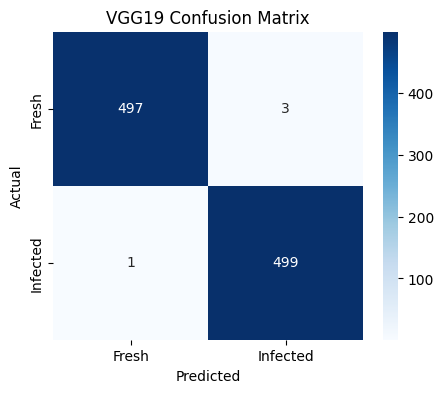


===== Classification Report =====

              precision    recall  f1-score   support

       Fresh   0.997992  0.994000  0.995992       500
    Infected   0.994024  0.998000  0.996008       500

    accuracy                       0.996000      1000
   macro avg   0.996008  0.996000  0.996000      1000
weighted avg   0.996008  0.996000  0.996000      1000


===== Performance Metrics =====
Accuracy : 0.996000
Precision: 0.994024
Recall   : 0.998000
F1-score : 0.996008


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# =========================================
# 🔹 1. PREDICT
# =========================================
y_pred = model_vgg19.predict(test_gen)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_gen.classes

# =========================================
# 🔹 2. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fresh", "Infected"],
            yticklabels=["Fresh", "Infected"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG19 Confusion Matrix")
plt.show()

# =========================================
# 🔹 3. CLASSIFICATION REPORT
# =========================================
print("\n===== Classification Report =====\n")
print(classification_report(y_true, y_pred, target_names=["Fresh", "Infected"], digits=6))

# =========================================
# 🔹 4. PERFORMANCE METRICS
# =========================================
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

print("\n===== Performance Metrics =====")
print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1-score : {f1:.6f}")

In [ ]:
# =========================================
# 🔹 VGG19 FEATURE EXTRACTOR
# =========================================
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

# =========================================
# 🔹 FEATURE EXTRACTION FUNCTION
# =========================================
def extract_features(generator):
    features, labels = [], []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)

        features.append(feat)
        labels.append(y_batch)

    X = np.vstack(features)
    y = np.hstack(labels)

    return X, y

# =========================================
# 🔹 EXTRACT FEATURES
# =========================================
train_gen.shuffle = False  # important

X, y = extract_features(train_gen)
print("Feature shape:", X.shape)

# =========================================
# 🔹 FEATURE SCALING
# =========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================================
# 🔹 CLASSIFIERS
# =========================================
classifiers = {
    "SVM": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42)
}

# =========================================
# 🔹 K-FOLD SETUP
# =========================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

# =========================================
# 🔹 TRAIN + EVALUATE
# =========================================
for name, clf in classifiers.items():
    print(f"\n===== {name} =====")

    accs, precs, recs, f1s = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        precs.append(precision_score(y_val, y_pred, average='macro'))
        recs.append(recall_score(y_val, y_pred, average='macro'))
        f1s.append(f1_score(y_val, y_pred, average='macro'))

        print(f"Fold {fold}: Acc={accs[-1]:.6f}, F1={f1s[-1]:.6f}")

    results[name] = {
        "acc": accs,
        "prec": precs,
        "rec": recs,
        "f1": f1s
    }

# =========================================
# 🔹 CONFIDENCE INTERVAL FUNCTION
# =========================================
def compute_ci(data):
    mean = np.mean(data)
    std = np.std(data)
    n = len(data)

    ci = stats.t.interval(
        0.95,
        df=n-1,
        loc=mean,
        scale=std/np.sqrt(n)
    )

    return mean, ci

# =========================================
# 🔹 FINAL RESULTS (6 DECIMAL + CI)
# =========================================
print("\n===== FINAL RESULTS (95% CI) =====")

for name in classifiers.keys():
    print(f"\n🔹 {name}")

    acc_mean, acc_ci = compute_ci(results[name]["acc"])
    f1_mean, f1_ci   = compute_ci(results[name]["f1"])
    prec_mean, prec_ci = compute_ci(results[name]["prec"])
    rec_mean, rec_ci   = compute_ci(results[name]["rec"])

    print(f"Accuracy : {acc_mean:.6f} ({acc_ci[0]:.6f}, {acc_ci[1]:.6f})")
    print(f"F1-score : {f1_mean:.6f} ({f1_ci[0]:.6f}, {f1_ci[1]:.6f})")
    print(f"Precision: {prec_mean:.6f} ({prec_ci[0]:.6f}, {prec_ci[1]:.6f})")
    print(f"Recall   : {rec_mean:.6f} ({rec_ci[0]:.6f}, {rec_ci[1]:.6f})")

Feature shape: (8000, 512)

===== SVM =====
Fold 1: Acc=0.996250, F1=0.996250
Fold 2: Acc=0.996250, F1=0.996250
Fold 3: Acc=0.998750, F1=0.998750
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=0.996250, F1=0.996250
Fold 6: Acc=0.997500, F1=0.997500
Fold 7: Acc=1.000000, F1=1.000000
Fold 8: Acc=0.995000, F1=0.995000
Fold 9: Acc=0.998750, F1=0.998750
Fold 10: Acc=0.996250, F1=0.996250

===== KNN =====
Fold 1: Acc=0.995000, F1=0.995000
Fold 2: Acc=0.995000, F1=0.995000
Fold 3: Acc=0.996250, F1=0.996250
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=1.000000, F1=1.000000
Fold 6: Acc=0.997500, F1=0.997500
Fold 7: Acc=0.996250, F1=0.996250
Fold 8: Acc=0.995000, F1=0.995000
Fold 9: Acc=0.997500, F1=0.997500
Fold 10: Acc=0.996250, F1=0.996250

===== RF =====
Fold 1: Acc=0.992500, F1=0.992500
Fold 2: Acc=0.997500, F1=0.997500
Fold 3: Acc=0.998750, F1=0.998750
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=1.000000, F1=1.000000
Fold 6: Acc=0.997500, F1=0.997500
Fold 7: Acc=0.997500, F1=0.997500
Fol